# Gene Report Module  
> This module focuses on the **GeneReports** class, which extends the capabilities of the AnnDataIso and TranscriptPlots classes to provide comprehensive gene-level analysis and visualization tools. It is specifically designed to handle gene expression data, offering specialized methods to efficiently manage and analyze data from various single-cell RNA sequencing protocols, facilitating seamless integration and manipulation within the Allos framework.  

As the field of single-cell RNA sequencing continues to advance, the Gene Report Module offers a robust and adaptable structure that can be extended to meet specific research needs. While it serves as a comprehensive foundation, we encourage the community to contribute by enhancing its capabilities and developing additional functionalities tailored to unique analytical requirements. This collaborative effort aims to build a dynamic ecosystem where users can leverage shared innovations and protocol-specific enhancements.  

The primary objective is to empower researchers to work effortlessly with gene-level single-cell RNA sequencing data in Allos, ensuring compatibility and efficiency across diverse datasets while benefiting from community-driven advancements.


In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
#| default_exp gene_report

In [4]:
#| export
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import csr_matrix
import anndata as ad
import seaborn as sns
import requests
import sys
import patchworklib as pw
import urllib
import os
import gzip
import shutil
import matplotlib.pyplot as plt
from scipy.special import gammaln
from scipy.optimize import minimize
from itertools import combinations
from typing import List, Tuple, Dict, Union, Optional
from functools import lru_cache
import pyranges as pr
from pyfaidx import Fasta
import logging
import base64
import io

from scipy.sparse import coo_matrix

from allos.anndata_iso import AnnDataIso
from allos.transcript_plots import TranscriptPlots

<Figure size 100x100 with 0 Axes>

In [ ]:

class GeneReports(TranscriptPlots, AnnDataIso):
    def __init__(self, anndata: ad.AnnData, palette='ghibli', gtf_file=None, reference_fasta=None):
        AnnDataIso.__init__(self, anndata, palette)
        TranscriptPlots.__init__(self,gtf_file, reference_fasta)

    # Plotting a summary of isoform-related metrics.
    def plot_isoforms_summary(self):
        """
        Generates a combined plot summarizing:
        1. Percentage of genes with multiple isoforms.
        2. Frequency distribution of isoforms per gene.
        3. Number of genes expressed per cell type.

        Returns:
        - Combined plot saved as an image.
        """
        ax1 = pw.Brick(figsize=(4, 4))
        self._plot_switch_gen_bar(ax1)
        ax1.set_title("Multiple isoforms genes %")
        ax2 = pw.Brick(figsize=(4, 4))
        self._plot_isoforms_frequencies(ax2)
        ax2.set_title("Frequency of isoforms per gene")
        ax3 = pw.Brick(figsize=(3, 2))
        self._plot_genes_cell_type(ax3)
        ax3.set_title("Nb of genes per cell type")
        return (ax1 | ax2 | ax3).savefig()

    # Private method to create a boxplot of genes expressed per cell type.
    def _plot_genes_cell_type(self, _ax):
        """
        Plots the number of genes expressed per cell type as a boxplot.

        Parameters:
        - _ax (Axes): Matplotlib axes to render the plot.
        """
        if _ax is None:
            df = pd.DataFrame(np.transpose(self.X), columns=self.obs['cell_type'])
            df = df.sum(axis=0).to_frame().reset_index()
            df.columns = ['cell_type', 'n_of_genes']
            ax = sns.boxplot(x='cell_type', y='n_of_genes', data=df)
            ax1 = sns.stripplot(x='cell_type', y='n_of_genes', data=df, color='black', size=3)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
            plt.show()
        else:
            df = pd.DataFrame(np.transpose(self.X), columns=self.obs['cell_type'])
            df = df.sum(axis=0).to_frame().reset_index()
            df.columns = ['cell_type', 'n_of_genes']
            sns.boxplot(x='cell_type', y='n_of_genes', data=df, ax=_ax)
            sns.stripplot(x='cell_type', y='n_of_genes', data=df, color='black', size=3, ax=_ax)
            _ax.set_xticklabels(_ax.get_xticklabels(), rotation=90)

    def plot_genes_cell_type(self):
        """
        Public method to plot the number of genes expressed per cell type.
        """
        self._plot_genes_cell_type(None)

    # Method to visualize isoform frequency distribution.
    def _plot_isoforms_frequencies(self, _ax):
    """
    Plots the frequency distribution of isoforms per gene.

    Parameters:
    - _ax (Axes): Matplotlib axes to render the plot.
    """
    # Compute isoform frequencies
    isoform_counts = self.gene_counts['transcriptId'].value_counts()
    
    # Find the maximum x-axis value (where counts are nonzero)
    max_x = isoform_counts.index.max()

    # Create the plot
    if _ax is None:
        fig, ax = plt.subplots()
        isoform_counts.plot(
            ax=ax, kind='bar', xlabel='number of isoforms per gene', ylabel='quantity of genes'
        )
    else:
        isoform_counts.plot(
            ax=_ax, kind='bar', xlabel='number of isoforms per gene', ylabel='quantity of genes'
        )
    
    # Set the x-axis limit dynamically
    ax.set_xlim(left=0, right=max_x + 1)  # Adding +1 for slight padding

    plt.show()

    def plot_isoforms_frequencies(self):
        """
        Public method to plot the frequency distribution of isoforms per gene.
        """
        self._plot_isoforms_frequencies(None)

    def plot_switch_gen_bar (self, _ax):
        self._plot_switch_gen_bar(None)

    def _plot_switch_gen_bar (self, _ax):
        if _ax is None:
            iso_per_gene = self.gene_counts
            x = ['genes']
            x1 = ['transcripts']
            multiple_iso = sum(iso_per_gene['transcriptId'] > 1)
            mono_iso = sum((iso_per_gene['transcriptId'] > 1) == False)
            labels = [str(round(1000*multiple_iso/(multiple_iso+mono_iso))/10) + '%', str(round(1000*mono_iso/(multiple_iso+mono_iso))/10) + '%']
            fig, ax = plt.subplots()
            mult = ax.bar(x, multiple_iso, label=labels[1], color=self.colors[0]) #multiple_iso/(multiple_iso+mono_iso))
            mono = ax.bar(x, mono_iso, bottom=multiple_iso, label=labels[0], color=self.colors[0]) #mona_iso/(multiple_iso+mono_iso))
            tran = ax.bar(x1, len(self.var['transcriptId']), color=self.colors[2])
            ax.text(
                ax.patches[0].get_x() + ax.patches[0].get_width() / 2, ax.patches[0].get_height() / 2, labels[0], ha="center", va="center"
                )
            ax.text(
                ax.patches[1].get_x() + ax.patches[1].get_width() / 2, ax.patches[1].get_height() / 2 + ax.patches[0].get_height(), labels[1], ha="center", va="center"
                )
            plt.legend(['Multiple isoforms', 'Single isoform'])
            plt.show()
        else:
            iso_per_gene = self.gene_counts
            x = ['genes']
            x1 = ['transcripts']
            multiple_iso = sum(iso_per_gene['transcriptId'] > 1)
            mono_iso = sum((iso_per_gene['transcriptId'] > 1) == False)
            labels = [str(round(1000*multiple_iso/(multiple_iso+mono_iso))/10) + '%', str(round(1000*mono_iso/(multiple_iso+mono_iso))/10) + '%']
            mult = _ax.bar(x, multiple_iso, label=labels[1], color=self.colors[0]) #multiple_iso/(multiple_iso+mono_iso))
            mono = _ax.bar(x, mono_iso, bottom=multiple_iso, label=labels[0], color=self.colors[1]) #mona_iso/(multiple_iso+mono_iso))
            tran = _ax.bar(x1, len(self.var['transcriptId']), color=self.colors[2])
            _ax.text(
                _ax.patches[0].get_x() + _ax.patches[0].get_width() / 2, _ax.patches[0].get_height() / 2, labels[0], ha="center", va="center"
                )
            _ax.text(
                _ax.patches[1].get_x() + _ax.patches[1].get_width() / 2, _ax.patches[1].get_height() / 2 + _ax.patches[0].get_height(), labels[1], ha="center", va="center"
                )
            _ax.legend(['Multiple isoforms', 'Single isoform'])
            plt.show()

    def plot_transcript_exspression_dotplot(self, gene_id, cell_labels_column='cell_type', top_n=5, ax=None):
        """
        Plot isoform expression for a selected gene across cell types,
        with dot color = average expression, and dot size = percent
        of cells expressing. Two legends: a colorbar for average
        expression, and a bubble-size legend for pct_expressing.

        DIFFERENT LAYOUT APPROACH:
        - We use a single figure+axes with plt.tight_layout(rect=[...])
        to reserve space on the right. 
        - We place the bubble-size legend as an "in-figure" legend
        using bbox_to_anchor, so it won't be cut off.
        """

        sns.set_theme(style='white', context='notebook')

        # ----------------------------------------------------
        # 1. Identify isoforms for the gene
        # ----------------------------------------------------
        isoforms = self.var[self.var['geneId'] == gene_id].index
        if len(isoforms) == 0:
            print(f"No isoforms found for gene ID: {gene_id}")
            return

        # (Optional) keep only top_n isoforms by overall average
        if top_n and len(isoforms) > top_n:
            overall_expr = self.to_df()[isoforms].mean()
            isoforms = overall_expr.sort_values(ascending=False).head(top_n).index

        # ----------------------------------------------------
        # 2. Average expression by cell type
        # ----------------------------------------------------
        avg_expr_list = []
        for iso in isoforms:
            means = self.to_df()[iso].groupby(self.obs[cell_labels_column], observed=False).mean()
            df_means = pd.DataFrame({
                cell_labels_column: means.index,
                'average_expression': means.values
            })
            df_means['isoform'] = iso
            avg_expr_list.append(df_means)
        avg_expr_df = pd.concat(avg_expr_list, ignore_index=True)

        # ----------------------------------------------------
        # 3. Percent of cells expressing each isoform
        # ----------------------------------------------------
        pct_expr_list = []
        for iso in isoforms:
            pct_expressing = self.to_df()[iso]\
                .groupby(self.obs[cell_labels_column], observed=False)\
                .apply(lambda x: (x > 0).mean() * 100)

            df_pct = pd.DataFrame({
                cell_labels_column: pct_expressing.index,
                'pct_expressing': pct_expressing.values
            })
            df_pct['isoform'] = iso
            pct_expr_list.append(df_pct)
        pct_expr_df = pd.concat(pct_expr_list, ignore_index=True)

        # ----------------------------------------------------
        # 4. Merge the average and pct data
        # ----------------------------------------------------
        plot_df = pd.merge(avg_expr_df, pct_expr_df,
                        on=['isoform', cell_labels_column],
                        how='left')

        # Drop columns that are all NaN or all zero
        plot_df.dropna(axis=1, how='all', inplace=True)
        numeric_cols = plot_df.select_dtypes(include=[np.number]).columns
        all_zero = (plot_df[numeric_cols] == 0).all(axis=0)
        plot_df.drop(columns=all_zero[all_zero].index, inplace=True)

        # ----------------------------------------------------
        # 5. Clean labels & drop blank cell types
        # ----------------------------------------------------
        plot_df['display_isoform'] = plot_df['isoform'].astype(str)
        plot_df['gene_isoform'] = gene_id + "–" + plot_df['display_isoform']

        plot_df = plot_df[plot_df[cell_labels_column].astype(str).str.strip() != '']

        # ----------------------------------------------------
        # 6. Filter out cell-types / isoforms with zero sums
        # ----------------------------------------------------
        plot_df = plot_df.groupby(cell_labels_column, observed=False).filter(
            lambda grp: (grp['average_expression'].sum() > 0) or
                        (grp['pct_expressing'].sum() > 0)
        )
        plot_df = plot_df.groupby('isoform', observed=False).filter(
            lambda grp: (grp['average_expression'].sum() > 0) or
                        (grp['pct_expressing'].sum() > 0)
        )

        # ----------------------------------------------------
        # 7. Convert to categorical + remove unused
        # ----------------------------------------------------
        plot_df[cell_labels_column] = plot_df[cell_labels_column].astype('category')
        plot_df['isoform'] = plot_df['isoform'].astype('category')
        plot_df[cell_labels_column] = plot_df[cell_labels_column].cat.remove_unused_categories()
        plot_df['isoform'] = plot_df['isoform'].cat.remove_unused_categories()

        # Sort so the x-axis follows category order
        cat_order = list(plot_df[cell_labels_column].cat.categories)
        plot_df[cell_labels_column] = plot_df[cell_labels_column].cat\
            .reorder_categories(cat_order, ordered=True)
        plot_df.sort_values(by=cell_labels_column, inplace=True)

        # ----------------------------------------------------
        # 8. Create figure & axes (no constrained layout)
        # ----------------------------------------------------
        fig_width = 25
        fig_height = max(5, plot_df['isoform'].nunique() * 0.8)
        if ax is None:
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        else:
            fig, _ = plt.subplots(figsize=(fig_width, fig_height))
        # We'll use tight_layout with rect=... to keep space on the right
        plt.tight_layout(rect=[0, 0, 0.78, 1])  # leave 22% on right side

        # ----------------------------------------------------
        # 9. Scatterplot: hue=average_expr, size=pct_expr
        # ----------------------------------------------------
        vmin = plot_df['average_expression'].min() if 'average_expression' in plot_df else 0
        vmax = plot_df['average_expression'].max() if 'average_expression' in plot_df else 1

        scatter = sns.scatterplot(
            data=plot_df,
            x=cell_labels_column,
            y='gene_isoform',
            hue='average_expression',     # color scale
            size='pct_expressing',        # bubble size
            palette='viridis',
            sizes=(50, 300),
            edgecolor='white',
            alpha=0.9,
            legend=False,  # We'll add custom legends
            hue_norm=plt.Normalize(vmin, vmax),
            ax=ax
        )

        ax.set_title(f'Differential Isoform Expression for {gene_id}', fontsize=16, pad=20)
        ax.set_xlabel('Cell Type', fontsize=13)
        ax.set_ylabel('Gene–Isoform', fontsize=13)
        sns.despine(ax=ax)

        # ----------------------------------------------------
        # 10. Color bar for average_expression
        # ----------------------------------------------------
        if 'average_expression' in plot_df:
            norm = plt.Normalize(vmin=vmin, vmax=vmax)
            sm = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=ax, fraction=0.05, pad=0.02)
            cbar.set_label('Average Expression', fontsize=16)

        # ----------------------------------------------------
        # 11. Bubble-size legend for pct_expressing
        #     We'll place it inside the figure to the right
        # ----------------------------------------------------
        if 'pct_expressing' in plot_df:
            size_bins = [0, 25, 50, 75, 100]
            size_handles = []
            for val in size_bins:
                # Map 0..100 to size range 50..300
                marker_size = np.interp(val, [0, 100], [50, 300])
                size_handles.append(
                    plt.scatter([], [], s=marker_size, color='gray',
                                alpha=0.9, edgecolor='white')
                )
            size_labels = [f"{int(val)}%" for val in size_bins]

            # Place bubble legend in the middle-right
            legend_size = ax.legend(
                size_handles,
                size_labels,
                title='Pct. Expressing',
                loc='center left',         # place vertically centered
                bbox_to_anchor=(1.08, 0.75),
                frameon=False,
                fontsize=10,
                title_fontsize=16
            )
            ax.add_artist(legend_size)

        # ----------------------------------------------------
        # 12. Final touches: rotate x labels, show plot
        # ----------------------------------------------------
        plt.xticks(rotation=45, ha='right', fontsize=16)
        plt.show()


    def plot_transcript_expression_violin(
        self,
        gene_id,
        cell_labels_column='cell_type',
        top_n=5,
        figsize_per_isoform=(4, 4)
    ):
        """
        Plot isoform expression for a selected gene across cell types,
        using violin plots (with each cell's expression as a point).

        Parameters
        ----------
        gene_id : str
            The gene ID to filter isoforms by (self.var['geneId']).
        cell_labels_column : str
            Column name in self.obs specifying the cell type or cluster label.
        top_n : int or None
            If not None, keeps only the top-n isoforms by overall mean expression.
        figsize_per_isoform : tuple
            Width and height (in inches) for each isoform subplot.
        """

        sns.set_theme(style='white', context='notebook')
        
        # ----------------------------------------------------
        # 1. Identify isoforms for the gene
        # ----------------------------------------------------
        isoforms = self.var[self.var['geneId'] == gene_id].index
        if len(isoforms) == 0:
            print(f"No isoforms found for gene ID: {gene_id}")
            return

        # (Optional) keep only top_n isoforms by overall average
        if top_n and len(isoforms) > top_n:
            overall_expr = self.to_df()[isoforms].mean()
            isoforms = overall_expr.sort_values(ascending=False).head(top_n).index

        # ----------------------------------------------------
        # 2. Collect expressions in a "long" DataFrame
        #    with columns: [cell_type, isoform, expression]
        # ----------------------------------------------------
        expr_df = self.to_df()[isoforms].copy()
        expr_df[cell_labels_column] = self.obs[cell_labels_column].values

        # Melt so that each row = one cell's expression for one isoform
        plot_df = expr_df.melt(
            id_vars=cell_labels_column, 
            var_name='isoform', 
            value_name='expression'
        )

        # Remove any cells that have an empty label
        plot_df = plot_df[plot_df[cell_labels_column].astype(str).str.strip() != '']
        
        # Remove any isoform or cell-type with zero expression across all cells.
        # Explicitly pass observed=False to retain the current behavior.
        plot_df = plot_df.groupby('isoform', observed=False).filter(lambda g: g['expression'].sum() > 0)
        plot_df = plot_df.groupby(cell_labels_column, observed=False).filter(lambda g: g['expression'].sum() > 0)

        # Make the cell type and isoform columns categorical (optional)
        plot_df[cell_labels_column] = plot_df[cell_labels_column].astype('category')
        plot_df['isoform'] = plot_df['isoform'].astype('category')

        # Sort categories so subplots come out in a stable order
        plot_df[cell_labels_column] = plot_df[cell_labels_column].cat.remove_unused_categories()
        plot_df['isoform'] = plot_df['isoform'].cat.remove_unused_categories()

        isoforms_used = plot_df['isoform'].cat.categories
        n_isoforms = len(isoforms_used)

        # ----------------------------------------------------
        # 3. Create subplots: one panel per isoform
        # ----------------------------------------------------
        fig_width = figsize_per_isoform[0] * n_isoforms
        fig_height = figsize_per_isoform[1]
        fig, axes = plt.subplots(
            1, n_isoforms,
            figsize=(fig_width, fig_height),
            sharey=True
        )

        # If there's only 1 isoform, wrap axes in a list for consistency
        if n_isoforms == 1:
            axes = [axes]

        # ----------------------------------------------------
        # 4. Plot each isoform's distribution using violin + strip
        # ----------------------------------------------------
        for i, iso in enumerate(isoforms_used):
            ax = axes[i]
            subset = plot_df[plot_df['isoform'] == iso]
            
            # Violin plot with updated parameters:
            # - Use density_norm='width' instead of scale='width'
            # - Set hue to cell_labels_column and legend=False to avoid deprecation warnings with palette.
            sns.violinplot(
                data=subset,
                x=cell_labels_column,
                y='expression',
                hue=cell_labels_column,
                ax=ax,
                density_norm='width',
                cut=0,
                palette='viridis',
                legend=False
            )
            
            # Strip plot (each cell as a point)
            sns.stripplot(
                data=subset,
                x=cell_labels_column,
                y='expression',
                ax=ax,
                color='k',
                size=2,
                alpha=0.6,
                dodge=True
            )
            
            ax.set_title(f"{gene_id} — {iso}", fontsize=12)
            ax.set_xlabel("")
            if i > 0:
                # Hide y label for all but the first subplot
                ax.set_ylabel("")

            # Rotate x-axis labels using plt.setp to avoid FixedLocator warnings
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

        # ----------------------------------------------------
        # 5. Final formatting
        # ----------------------------------------------------
        fig.suptitle(f'Violin plots of expression for {gene_id}', fontsize=14)
        sns.despine(left=True, bottom=True)
        plt.tight_layout()
        plt.show()

    # def _trsct_counts_cell_type (self, gene_name, trs_to_show, _ax):
    #     if _ax is None:
    #     # create df with filtered isoform counts and labeled cell types:
    #         df = self._filtered_anndata.to_df().set_index(self._filtered_anndata.obs['cell_type'])
    #         # df = df.transpose()
    #         df['geneId'] = self._filtered_anndata.var['geneId']
    #         df['transcriptId'] = self._filtered_anndata.var.index.to_frame()
    #         df['cell_type'] = self._filtered_anndata.obs['cell_type']
    #         gene_iso_count = df[df['geneId'] == gene_name]
    #         gene_iso_count = gene_iso_count.drop('geneId', axis=1).set_index('transcriptId') # .transpose()
    #         gene_iso_count_long = gene_iso_count.reset_index().melt(id_vars='cell_type', var_name='transcriptId', value_name='count')
    #         if trs_to_show != []:
    #             gene_iso_count_long = gene_iso_count_long[gene_iso_count_long['transcriptId'].isin(trs_to_show)]
    #         g = sns.catplot(x="cell_type", y="count", col="transcriptId", aspect=1, dodge=False, kind="violin", data=gene_iso_count_long, palette=self.colors)
    #         # Set custom facet titles
    #         g.set_titles(col_template="{col_name}", size = 8)
    #         # Remove x ticks
    #         g.set_xticklabels(rotation=90)
    #         g.fig.suptitle(gene_name)
    #         plt.show()
    #     else:
    #         df = self._filtered_anndata.to_df ().set_index(self._filtered_anndata.obs['cell_type'])
    #         # df = df.transpose()
    #         df[['geneId']] = self._filtered_anndata.var[['geneId']]
    #         df[['transcriptId']] = self._filtered_anndata.var.index.to_frame()
    #         gene_iso_count = df[df['geneId']== gene_name]
    #         gene_iso_count = gene_iso_count.drop('geneId', axis=1).set_index('transcriptId').transpose()
    #         gene_iso_count_long = gene_iso_count.reset_index().melt(id_vars='cell_type', var_name='transcriptId', value_name='count')
    #         if trs_to_show != []:
    #             gene_iso_count_long = gene_iso_count_long[gene_iso_count_long['transcriptId'].isin(trs_to_show)]
    #         g = sns.catplot(x="cell_type", y="count", col="transcriptId", aspect=1, dodge=False, kind="violin", data=gene_iso_count_long, palette=self.colors)
    #         # Set custom facet titles
    #         g.set_titles(col_template="{col_name}", size = 8)
    #         # Remove x ticks
    #         g.set_xticklabels(rotation=90, labels=self.obs['cell_type'].unique())
    #         g.fig.suptitle(gene_name)
    #         return g

    # def trsct_counts_cell_type (self, gene_name, trs_to_show = []):
    #     # create df with filtered isoform counts and labeled cell types:
    #     self._trsct_counts_cell_type(gene_name, trs_to_show, None)

    def _plot_transcripts_per_cell_type(self, gene_name, trs_to_show, _ax):
        if trs_to_show == []:
            transcripts_id = self._get_transcripts_from_gene(gene_name)
        else:
            transcripts_id = trs_to_show
        if _ax is None:
            fig, ax = plt.subplots()
            grouped = self._filtered_anndata.obsm['Iso_prct']
            grouped['cell_type'] = self.obs['cell_type']
            res = grouped.groupby('cell_type').mean().transpose()
            res = res.assign(transcriptId=self._filtered_anndata.var['transcriptId'].to_list())
            res = res.assign(geneId=self._filtered_anndata.var['geneId'].to_list())
            res = res[res['geneId'] == gene_name].drop(['geneId'], axis=1)
            res = res[res['transcriptId'].isin(transcripts_id)]
            plot_data = res.set_index('transcriptId').transpose()
            plot_data.plot(kind='barh', ax=ax, stacked=True, color=self.colors).legend(loc='center left',bbox_to_anchor=(1.0, 1.0))
            plt.legend(self.get_transcripts_common_names(transcripts_id), loc="upper left", bbox_to_anchor=(1, 1))
            #plt.legend(self.get_transcripts_common_names(trs_to_show))
            plt.ylabel('Cell type')
        else:
            grouped = self._filtered_anndata.obsm['Iso_prct']
            grouped['cell_type'] = self.obs['cell_type']
            res = grouped.groupby('cell_type').mean().transpose()
            res = res.assign(transcriptId=self._filtered_anndata.var['transcriptId'].to_list())
            res = res.assign(geneId=self._filtered_anndata.var['geneId'].to_list())
            res = res[res['geneId'] == gene_name].drop(['geneId'], axis=1)
            res = res[res['transcriptId'].isin(transcripts_id)]
            plot_data = res.set_index('transcriptId').transpose()
            plot_data.plot(kind='barh', stacked=True, ax=_ax, color=self.colors).legend(loc='center left',bbox_to_anchor=(1.0, 1.0))

    def plot_transcripts_per_cell_type(self, gene_name, trs_to_show = []):
        self._plot_transcripts_per_cell_type(gene_name, trs_to_show, None)

    def _get_transcripts_from_gene(self, gene_name):
        elems = self._filtered_anndata.var
        return elems[elems['geneId'] == gene_name]['transcriptId'].to_list()

    def _draw_transcripts_list_from_gene(self, gene_name, trs_to_show, _ax, colors=None):
        if trs_to_show == []:
            transcripts_id = self._get_transcripts_from_gene(gene_name)
        else:
            transcripts_id = trs_to_show
        exons = []
        directions = []
        for tr in transcripts_id:
            t, d = self._get_coord_from_tscrpt_id(tr)
            exons += [t]
            directions += [d]
        if colors is None:
            colors = []
            for i in range(len(exons)):
                colors.append(self.colors[i % len(self.colors)])
        def get_limits(ex, dir):
            start = sys.maxsize
            end = -sys.maxsize
            for (e, d) in zip(ex, dir):
                if d == 1:
                    start = min(start,e[0][1])
                    end = max(end, e[-1][0])
                else:
                    start = min(start,e[-1][1])
                    end = max(end, e[0][0])
            return (start, end)
        plt.axes()
        plt.xlim((-0.1, 1.1))
        plt.ylim((0.1 - 0.5 *  len(exons), 0.3))
        plt.margins(0.2)
        plt.axis('off')
        fig = plt.gcf()
        fig.set_size_inches(20, len(exons) * 2)
        i = 0
        (start, end) = get_limits(exons, directions)
        for (ex, di, co, name) in zip(exons, directions, colors, transcripts_id):
            self._draw_transcript(ex, di, co, name, offset= -0.5 * i, start_override=start, end_override=end, no_render=True)
            i+=1
        if _ax is None:
            plt.show()
        else:
            return plt

    def draw_transcripts_list_from_gene(self, gene_name, colors=None):
        self._draw_transcripts_list_from_gene(gene_name, [], None, colors)

    def draw_gene_summary(self, gene_name, trs_to_show = []):
        ax1 = pw.Brick(figsize=(12,4))
        pw.overwrite_axisgrid()
        fg = self._trsct_counts_cell_type(gene_name, trs_to_show, ax1)
        ax4 = pw.load_seaborngrid(fg)
        ax1.set_title("Transcripts count per cell type")
        ax2 = pw.Brick(figsize=(12,4))
        self._plot_transcripts_per_cell_type(gene_name, trs_to_show, ax2)
        ax2.set_title("Transcripts count per cell type")
        ax3 = pw.Brick(figsize=(12,4))
        self._draw_transcripts_list_from_gene(gene_name, trs_to_show, ax3)
        ax3.set_title("Transcripts list")
        return (ax4/(ax2/ax3)).savefig()

    def _draw_transcript_alt(self, exons, direction, color, transcript_name, mapping_fn,
                         offset=0, with_cds=False, ax=None):
        """
        Draw the exons/introns in a single transcript using the global mapping_fn,
        so everything lines up across transcripts with identical coordinates.
        This version preserves the original exon shapes (including UTR/CDS splits on first and last exons)
        but removes any special CDS coloring.
        """
        height = 0.2
        cache = {}
        def cached_map(x):
            if x not in cache:
                cache[x] = mapping_fn(x)
            return cache[x]

        j, k = (0, 1) if direction == 1 else (1, 0)

        if with_cds:
            t_info = self.get_transcript_info(transcript_name)
            cds_start, cds_end = t_info['cds_start'], t_info['cds_end']
        else:
            cds_start = cds_end = None

        # Draw introns
        for i in range(len(exons) - 1):
            intron_start = cached_map(exons[i][j])
            intron_end   = cached_map(exons[i + 1][k])
            ax.plot([intron_start, intron_end],
                    [offset + 0.1, offset + 0.1],
                    color='black', linestyle='-', linewidth=1, zorder=0)

        # Draw exons (UTR/CDS, if available)
        for idx, exon in enumerate(exons):
            exon_start_gen = exon[j]
            exon_end_gen   = exon[k]
            scaled_exon_start = cached_map(exon_start_gen)
            scaled_exon_end   = cached_map(exon_end_gen)
            width = scaled_exon_end - scaled_exon_start
            base_color = color
            base_edgecolor = 'black'

            if with_cds and (cds_start is not None) and (cds_end is not None):
                left_exon = min(exon_start_gen, exon_end_gen)
                right_exon = max(exon_start_gen, exon_end_gen)
                coding_left = max(left_exon, cds_start)
                coding_right = min(right_exon, cds_end)
                coding_exists = coding_left < coding_right

                if idx == 0 or idx == len(exons) - 1:
                    # First/last exon: possibly split UTR/CDS if needed
                    if coding_exists:
                        # Left UTR
                        if left_exon < coding_left:
                            scaled_utr_left = cached_map(left_exon)
                            scaled_utr_right = cached_map(coding_left)
                            utr_width = scaled_utr_right - scaled_utr_left
                            utr_height = height * 0.6
                            rect_utr = plt.Rectangle((scaled_utr_left, offset + (height - utr_height) / 2),
                                                     utr_width, utr_height,
                                                     fc=base_color, ec=base_edgecolor, zorder=1)
                            ax.add_patch(rect_utr)
                        # CDS
                        scaled_cds_left = cached_map(coding_left)
                        scaled_cds_right = cached_map(coding_right)
                        cds_width = scaled_cds_right - scaled_cds_left
                        rect_cds = plt.Rectangle((scaled_cds_left, offset), cds_width, height,
                                                 fc=base_color, ec=base_edgecolor, zorder=1)
                        ax.add_patch(rect_cds)
                        # Right UTR
                        if coding_right < right_exon:
                            scaled_utr_left = cached_map(coding_right)
                            scaled_utr_right = cached_map(right_exon)
                            utr_width = scaled_utr_right - scaled_utr_left
                            utr_height = height * 0.6
                            rect_utr = plt.Rectangle((scaled_utr_left, offset + (height - utr_height) / 2),
                                                     utr_width, utr_height,
                                                     fc=base_color, ec=base_edgecolor, zorder=1)
                            ax.add_patch(rect_utr)
                    else:
                        # Entirely non-coding
                        rect = plt.Rectangle((scaled_exon_start, offset + (height - height * 0.6) / 2),
                                             width, height * 0.6,
                                             fc=base_color, ec=base_edgecolor, zorder=1)
                        ax.add_patch(rect)
                    continue
                else:
                    # Middle exons
                    if coding_exists:
                        rect = plt.Rectangle((scaled_exon_start, offset), width, height,
                                             fc=base_color, ec=base_edgecolor, zorder=1)
                    else:
                        rect = plt.Rectangle((scaled_exon_start, offset), width, height * 0.6,
                                             fc=base_color, ec=base_edgecolor, zorder=1)
                    ax.add_patch(rect)
                    continue
            else:
                # No CDS info: draw a full-height exon
                rect = plt.Rectangle((scaled_exon_start, offset), width, height,
                                     fc=base_color, ec=base_edgecolor, zorder=1)
                ax.add_patch(rect)

        # Direction arrow
        arrow_y = offset - height/4
        if direction > 0:
            ax.arrow(0, arrow_y, 1, 0,
                     width=0.0015, head_length=0.01, head_width=0.1,
                     length_includes_head=True, overhang=1,
                     color='black')
        else:
            ax.arrow(1, arrow_y, -1, 0,
                     width=0.0015, head_length=0.01, head_width=0.1,
                     length_includes_head=True, overhang=1,
                     color='black')

        # Tick marks for transcript boundaries
        if direction == 1:
            real_start = exons[0][1]
            real_end   = exons[-1][0]
        else:
            real_start = exons[-1][1]
            real_end   = exons[0][0]

        scaled_real_start = cached_map(real_start)
        scaled_real_end   = cached_map(real_end)

        ax.plot([scaled_real_start, scaled_real_start],
                [arrow_y - 0.03, arrow_y + 0.03], color='black')
        ax.plot([scaled_real_end, scaled_real_end],
                [arrow_y - 0.03, arrow_y + 0.03], color='black')

        ax.text(scaled_real_start, arrow_y - 0.06,
                str(real_start), ha='center', va='top', fontsize=9)
        ax.text(scaled_real_end, arrow_y - 0.06,
                str(real_end), ha='center', va='top', fontsize=9)

        # Transcript name on right
        ax.text(1, offset - height,
                transcript_name, ha='right', va='top', fontsize=12)

    def _draw_transcripts_list_to_jpeg_base_64(self, transcripts_ids, colors=None, draw_cds=False):
        """
        Draw multiple transcripts with the same global mapping,
        ensuring that exons sharing coordinates line up perfectly.
        """
        my_stringIObytes = io.BytesIO()
        ax1 = pw.Brick(figsize=(12,4))
        exons_list   = []
        directions   = []
        for tr in transcripts_ids:
            t, d = self._get_coord_from_tscrpt_id(tr)
            exons_list.append(t)
            directions.append(d)

        if colors is None:
            colors = [self.colors[i % len(self.colors)] for i in range(len(exons_list))]

        mapping_fn = self._make_global_mapping(exons_list)

        plt.close('all')
        plt.figure()
        plt.axes()
        plt.xlim(-0.05, 1.05)
        plt.ylim((0.1 - 0.5 * len(exons_list), 0.3))
        plt.margins(0.2)
        plt.axis('off')

        fig = plt.gcf()
        fig.set_size_inches(20, len(exons_list) * 2)

        for i, (ex, di, co, tid) in enumerate(zip(exons_list, directions, colors, transcripts_ids)):
            offset = -0.5 * i
            self._draw_transcript_alt(ex, di, co, tid, mapping_fn,
                                  offset=offset, with_cds=draw_cds, ax=ax1)
        ax1.savefig(my_stringIObytes, format='jpg')
        my_stringIObytes.seek(0)
        return base64.b64encode(my_stringIObytes.read()).decode()

    def _plot_isoforms_summary_to_jpeg_base64(self):
        my_stringIObytes = io.BytesIO()
        ax1 = pw.Brick(figsize=(4, 4))
        self._plot_switch_gen_bar(ax1)
        ax1.set_title("Multiple isoforms genes %")
        ax2 = pw.Brick(figsize=(4, 4))
        self._plot_isoforms_frequencies(ax2)
        ax2.set_title("Frequency of isoforms per gene")
        ax3 = pw.Brick(figsize=(3, 2))
        self._plot_genes_cell_type(ax3)
        ax3.set_title("Nb of genes per cell type")
        (ax1 | ax2 | ax3).savefig(my_stringIObytes, format='jpg')
        my_stringIObytes.seek(0)
        return base64.b64encode(my_stringIObytes.read()).decode()
    
    def plot_transcripts(self, gene_id=None, transcripts=None):
        """
        Plot the UMAP with the specified transcripts or transcripts associated with the given gene ID.
        
        Parameters:
        -----------
        gene_id : str, optional
            The gene ID for which to find and plot associated transcripts. 
            Ignored if `transcripts` is provided.
        transcripts : list of str, optional
            A list of transcript IDs to plot. If provided, `gene_id` is ignored.
        
        Returns:
        --------
        None
            Displays the UMAP plot colored by the specified transcripts.
        """
        my_stringIObytes = io.BytesIO()
        ax1 = pw.Brick(figsize=(4, 4))
        if transcripts is None:
            if gene_id is None:
                raise ValueError("Either `gene_id` or `transcripts` must be provided.")
            # Select transcripts associated with the provided gene ID
            transcripts = self[:, self.var['geneId'] == gene_id].var.index.to_list()
        
        # Plot UMAP
        sc.pl.umap(self, color=transcripts, ax=ax1)
        ax1.savefig(my_stringIObytes, format='jpg')
        my_stringIObytes.seek(0)
        return base64.b64encode(my_stringIObytes.read()).decode()

    
    # def write_gene_report(self, gene_id, filename='report.html'):
    #     with open(filename, 'w') as f:
    #         f.write("<html><head><title>Gene report</title></head><body>")
    #         f.write("<h1>Gene report</h1>")
    #         f.write("<h2>Isoforms summary</h2>")
    #         f.write('<img src="data:image/jpeg;base64,{0}" style="width: 100%">'.format(self._plot_isoforms_summary_to_jpeg_base64()))
    #         f.write("<p>Below is a summary of the isoforms</p>")
    #         f.write("<h2>Transcripts</h2>")
    #         my_stringIObytes = io.BytesIO()
    #         ax1 = pw.Brick(figsize=(4, 4))
    #         self.plot_transcript_exspression_dotplot(gene_id, ax=ax1)
    #         ax1.savefig(my_stringIObytes, format='jpg')
    #         my_stringIObytes.seek(0)
    #         figure_b64 = base64.b64encode(my_stringIObytes.read()).decode()
    #         f.write('<img src="data:image/jpeg;base64,{0}" style="width: 100%">'.format(figure_b64))
    #         f.write("<h2>Transcripts</h2>")
    #         f.write("<ul>")
    #         for transcript_id in self.var[self.var['geneId']==gene_id]["transcriptId"].unique():
    #             f.write("<li>%s" % transcript_id)
    #             f.write("<img src='data:image/jpeg;base64,{0}' style='width: 50%'>".format(self.plot_transcripts(transcripts=[transcript_id])))
    #             f.write("</li>")
    #         f.write("</ul>")
    #         f.write("</body></html>")
    # def generate_quarto_report(self, gene_id, output_file="gene_report.html"):
    #     """
    #     Generates a Quarto report by passing the gene_id dynamically.
    #     """
    #     # Read Quarto template
    #     with open("report_template.qmd", "r") as template_file:
    #         template_content = template_file.read()

    #     # Fill template with gene_id
    #     report_content = jinja2.Template(template_content).render(gene_id=gene_id)

    #     # Save updated Quarto file
    #     with open("generated_gene_report.qmd", "w") as output_file:
    #         output_file.write(report_content)

    #     # Render the report to HTML (or PDF)
    #     subprocess.run(["quarto", "render", "generated_gene_report.qmd", "--to", "html"])

    #     print(f"✅ Quarto report generated successfully: gene_report.html")

    # More detailed functions omitted for brevity.

Make use of Wilcoxon results and/or dirichlet results if the Switch search was run 

In [6]:
from allos.readers_tests import *
import allos.preprocessing as pp
combined_mouse_data = process_mouse_data()
combined_mouse_data = pp.filter_transcripts_by_abundance(combined_mouse_data,  threshold_pct= 2)



🔎 Looking for file at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/e18.mouse.clusters.csv
✅ File found at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/e18.mouse.clusters.csv
✅ File already exists at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt.gz

🔄 Decompressing /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt.gz to /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_1.txt...
✅ Decompression complete.
Test data (mouse_1) downloaded successfully
✅ File already exists at: /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt.gz

🔄 Decompressing /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt.gz to /home/diamant/.conda/envs/iso_swt/lib/python3.9/site-packages/allos/resources/data/mouse_2.txt...
✅ Decom

In [ ]:
# | hide
# class AnnDataIso(ad.AnnData):
#     # Private method to filter dataset for genes with multiple isoforms.
#     def _filter_isodata(self):
#         """
#         Filters the data to include only genes with multiple isoforms.

#         Logic:
#         - Counts the number of isoforms for each gene using `np.unique`.
#         - Creates a DataFrame with gene IDs and their isoform counts.
#         - Identifies genes with more than one isoform.
#         - Subsets the AnnData object to include only these genes.

#         Returns:
#         - Filtered AnnData object with only genes having multiple isoforms.
#         """
#         genes, frequencies = np.unique(self.var['geneId'], return_counts=True)
#         df = pd.DataFrame({"geneId": genes, "frequencies": frequencies})
#         multi_iso_genes = df[df["frequencies"] > 1]['geneId'].tolist()
#         filtr_adata_iso = self[:, self.var['geneId'].isin(multi_iso_genes)]
#         return filtr_adata_iso

#     # Method to compute isoform expression percentages relative to total gene expression.
#     def iso_percent(self):
#         """
#         Calculates isoform expression percentages for each barcode.

#         Parameters:
#         - df (DataFrame): Input DataFrame containing isoform expression data.

#         Returns:
#         - DataFrame with normalized isoform percentages for each barcode.
#         """
#         def get_sot_gene_matrix(adata):
#             # gene_ids must be something like adata.var['geneId']
#             gene_ids = adata.var['geneId'].values
            
#             # Find the unique gene IDs and map each transcript to one of these genes
#             unique_gene_ids, inverse = np.unique(gene_ids, return_inverse=True)
            
#             # Convert adata.X to a COO matrix (cheap if already sparse)
#             X_coo = coo_matrix(adata.X)

            
#             # Re-map the column indices: each old column index -> new gene index
#             new_row = X_coo.row
#             new_col = inverse[X_coo.col]
#             new_data = X_coo.data
            
#             # Build the new sparse matrix
#             # (COO duplicates are summed when converting to CSR/CSC)
#             new_coo = coo_matrix(
#                 (new_data, (new_row, new_col)),
#                 shape=(adata.n_obs, len(unique_gene_ids))
#             )
#             new_X = new_coo.tocsr()  # or .tocsc(), whichever you prefer
            
#             # Build a new AnnData object at gene level
#             adata_gene_level = sc.AnnData(
#                 X=new_X,
#                 obs=adata.obs.copy(),
#                 var=pd.DataFrame(index=unique_gene_ids)
#             )

#             adata_gene_level.var.index.names = ['geneId']

            
#             return adata_gene_level
#         gene_adata = get_sot_gene_matrix(self)
#         gene_ids = self.var['geneId'].values
#         _, inverse = np.unique(gene_ids, return_inverse=True)
        
#         def to_dense(matrix):
#             return matrix.toarray() if hasattr(matrix, "toarray") else matrix
        
#         transcript_counts = to_dense(self.X)
#         gene_counts = to_dense(gene_adata.X)
#         denominator = gene_counts[:, inverse]
        
#         with np.errstate(divide='ignore', invalid='ignore'):
#             pct = np.divide(
#                 transcript_counts,
#                 denominator,
#                 out=np.zeros_like(transcript_counts, dtype=float),
#                 where=denominator != 0
#             )
#         pct *= 100
        
#         new_adata = sc.AnnData(X=pct, obs=self.obs.copy(), var=self.var.copy())
#         return new_adata

#     # Class initializer to process the AnnData object and compute relevant annotations.
#     def __init__(self, anndata: ad.AnnData, palette='ghibli'):
#         """
#         Initializes the AnnDataIso object with isoform and gene-level annotations.

#         Parameters:
#         - anndata (AnnData): Input AnnData object containing isoform-level data.
#         - cell_types (DataFrame): DataFrame with cell type annotations.
#         """
#         self._init_as_actual(anndata.copy())
#         # Group genes and count the number of isoforms.
#         self.gene_counts = self.var.reset_index().groupby(by='geneId').count()
#         # Filter dataset for genes with multiple isoforms.
#         self._filtered_anndata = self._filter_isodata()
#         # Annotate cell types in the observation data.
#         # Compute isoform percentages.
#         if 'barcodes' in self._filtered_anndata.obs.columns:
#             df = self._filtered_anndata.to_df().set_index(self._filtered_anndata.obs['barcodes'])
#         else:
#             df = self._filtered_anndata.to_df()
#         df[['geneId']] = self._filtered_anndata.var[['geneId']]
#         self.var[['transcriptId']] = self._filtered_anndata.var.index.to_frame()
#         df[['transcriptId']] = self._filtered_anndata.var.index.to_frame()
#         df_m_iso = self.iso_percent().to_df()
#         self._filtered_anndata.obsm['Iso_prct'] = df_m_iso
#         self.colors = ['#6c6246', '#387041', '#153c27', '#393525', '#b19c77', '#175934', '#d0e7f3', '#466175', '#8c8c5a', '#47462c', '#8c414e', '#579f4e', '#7cb282', '#30363a', '#672c37', '#e5c6ad', '#402b2f', '#b0606e', '#c1e5d8', '#829ea7']
#         if palette != 'ghibli':
#             self.colors = ['#100856', '#7243ee', '#da2ad3', '#3a58a4', '#2d149e', '#7f0d9a', '#3b0554', '#7a97f4', '#a127b4', '#696e43', '#de62e2', '#4e1af5', '#88904e', '#2d2c18', '#576d5c', '#4a4f20', '#909cfa', '#929574', '#c905ca', '#71a493']


         Falling back to preprocessing with `sc.pp.pca` and default params.


2025-03-14 15:01:57.655022: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-14 15:01:57.671517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741960917.689676 1232644 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741960917.694940 1232644 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 15:01:57.715286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

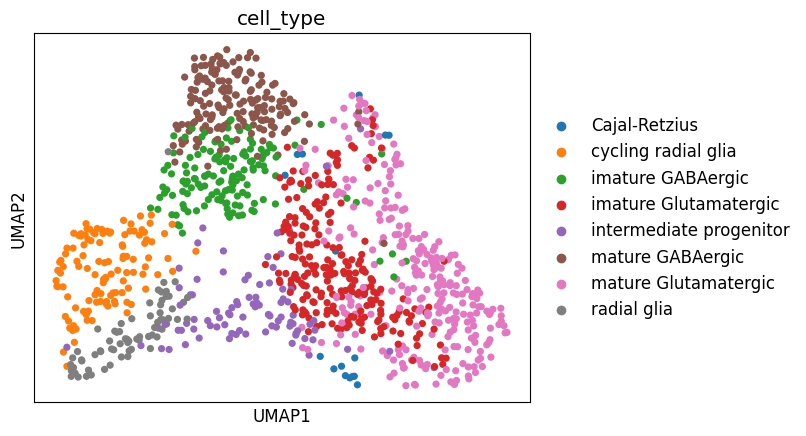

In [8]:
import allos.visuals as vs
sc.pp.normalize_total(combined_mouse_data, target_sum=1e6)
sc.pp.log1p(combined_mouse_data)
sc.pp.neighbors(combined_mouse_data)
sc.tl.umap(combined_mouse_data)
sc.pl.umap(combined_mouse_data, color = 'cell_type')

In [12]:
gene_reports = GeneReports(combined_mouse_data)

TypeError: iso_percent() missing 1 required positional argument: 'df'

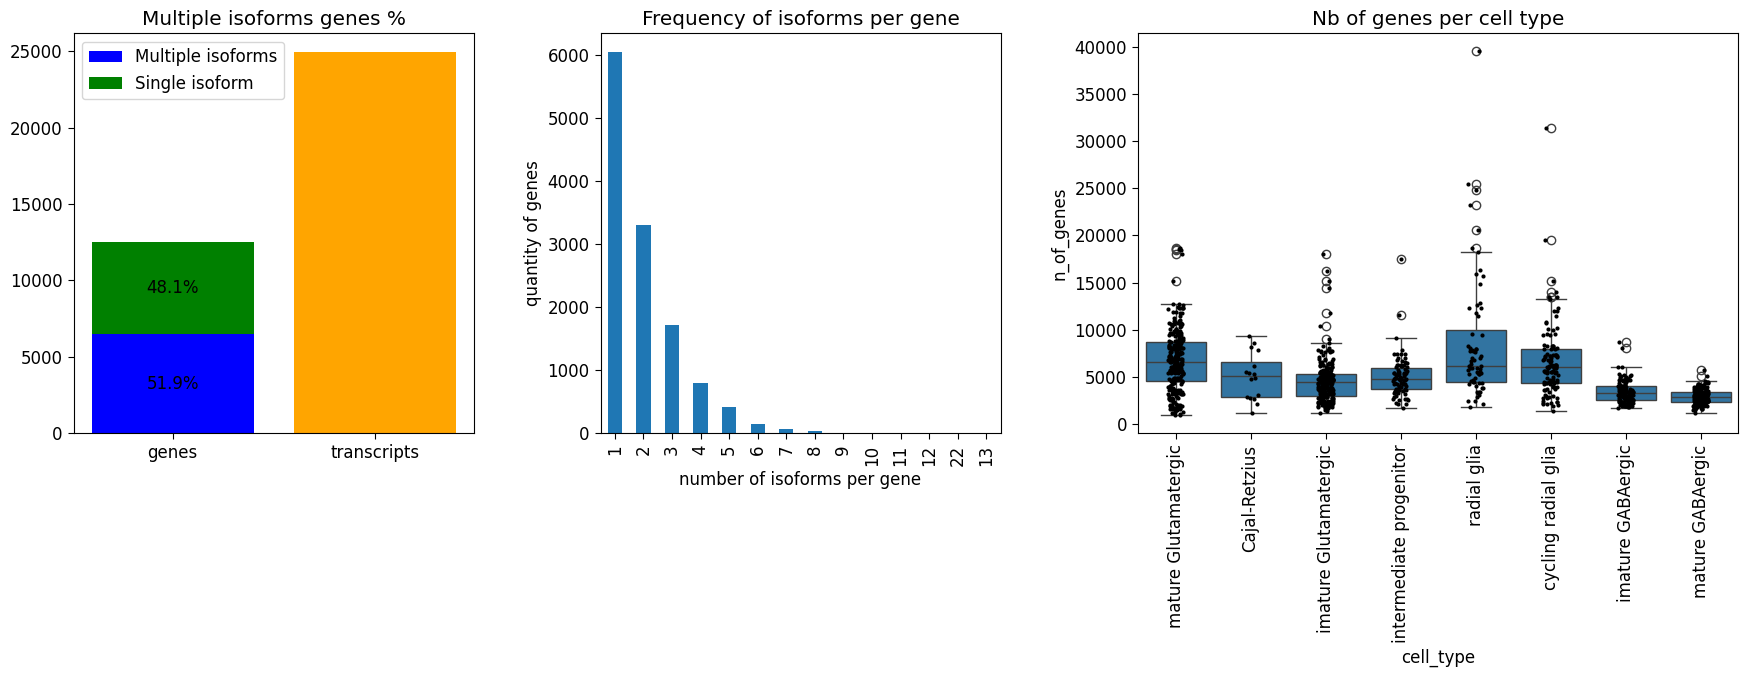

In [124]:
gene_reports.plot_isoforms_summary()

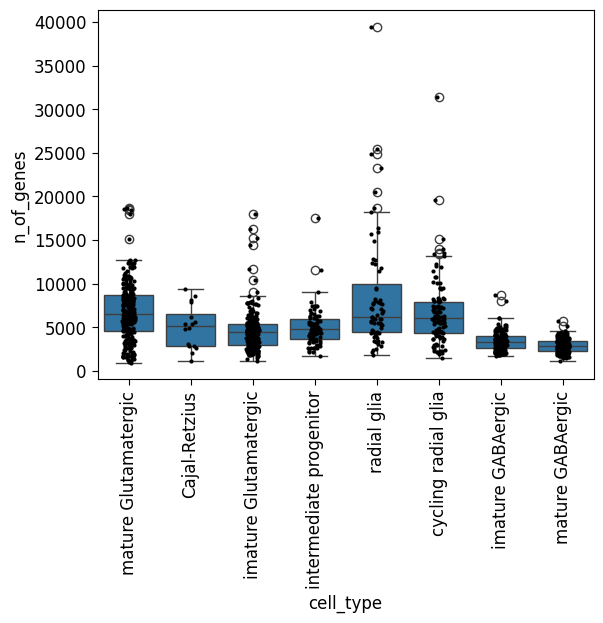

In [125]:
gene_reports.plot_genes_cell_type()

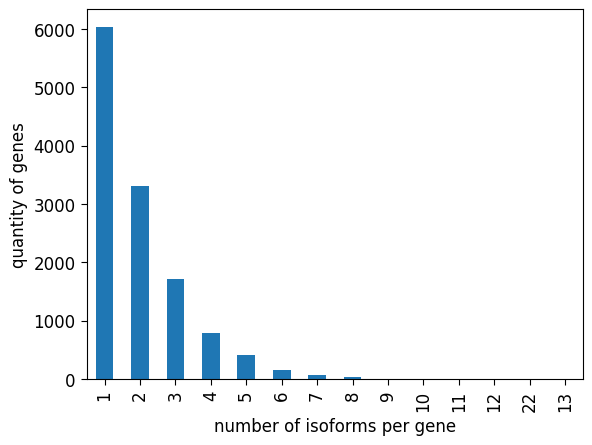

In [126]:
gene_reports.plot_isoforms_frequencies()

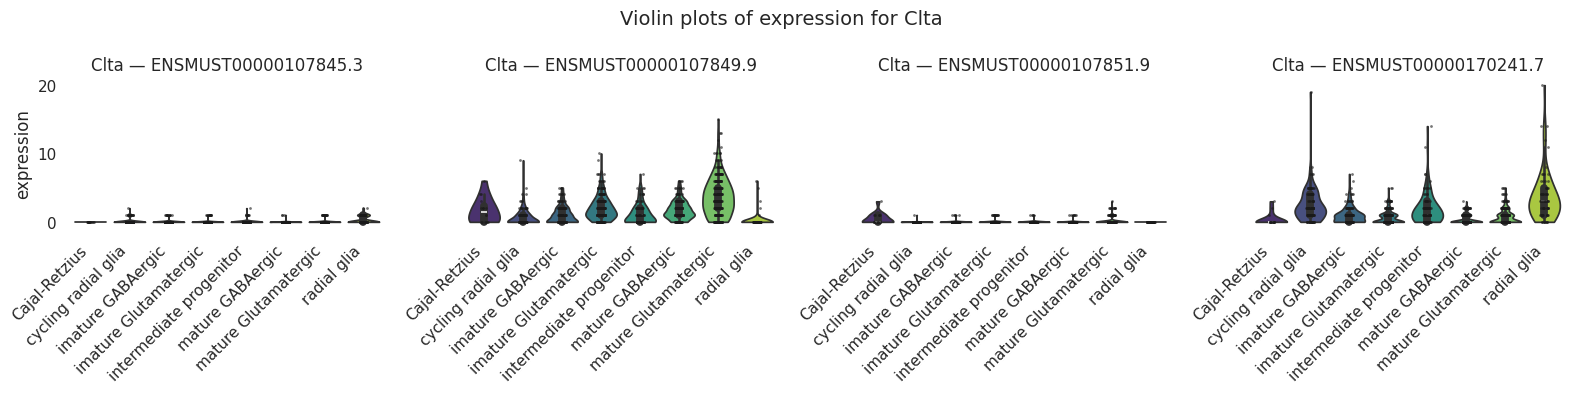

In [145]:
gene_reports.plot_transcript_expression_violin("Clta")

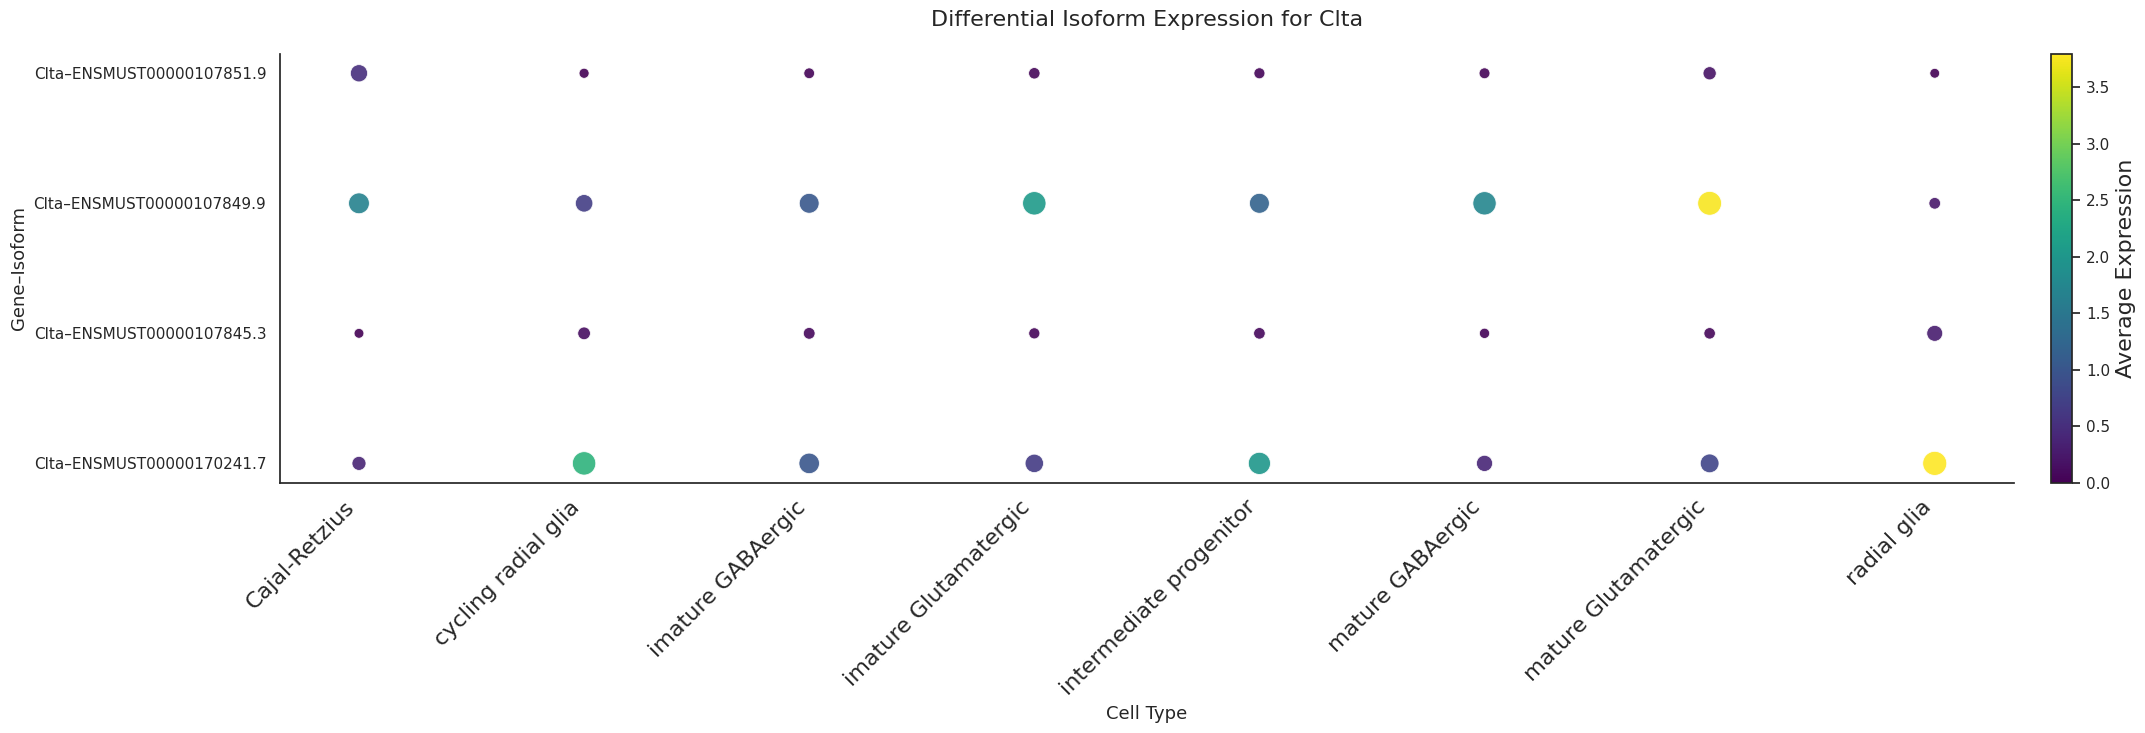

In [156]:
gene_reports.plot_transcript_exspression_dotplot("Clta")

In [1]:
#gene_reports.write_gene_report("Clta")